In [25]:
!pip install pandas scikit-learn nltk vaderSentiment

In [26]:
import pandas as pd
import re
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_excel('/content/edufeed_clean_data.xlsx')
df = df[['comments', 'sentiment_label']]
df.dropna(inplace=True)

In [29]:
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)
df['comment_processed'] = df['comments'].apply(clean_text)

In [30]:
def anonymize_text(text):
    text = re.sub(r'\S+@\S+', 'EMAIL', text)
    text = re.sub(r'\d+', 'NUMBER', text)
    text = re.sub(r'\b[A-Z][a-z]+\b', 'NAME', text)
    return text
df['anonymous_comment'] = df['comment_processed'].apply(anonymize_text)

In [31]:
analyzer = SentimentIntensityAnalyzer()
def vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"
df['vader_prediction'] = df['anonymous_comment'].apply(vader_sentiment)

In [32]:
print("VADER Accuracy:", accuracy_score(df['sentiment_label'], df['vader_prediction']))
print(classification_report(df['sentiment_label'], df['vader_prediction']))

VADER Accuracy: 0.6640636732242078
              precision    recall  f1-score   support

    Negative       0.74      0.44      0.55      5669
     Neutral       0.12      0.09      0.10      2505
    Positive       0.72      0.89      0.79     11803

    accuracy                           0.66     19977
   macro avg       0.53      0.47      0.48     19977
weighted avg       0.65      0.66      0.64     19977



In [33]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['anonymous_comment'])
y = df['sentiment_label']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [36]:
y_pred = model.predict(X_test)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7617617617617618
              precision    recall  f1-score   support

    Negative       0.76      0.69      0.73      1174
     Neutral       0.38      0.08      0.14       476
    Positive       0.78      0.94      0.85      2346

    accuracy                           0.76      3996
   macro avg       0.64      0.57      0.57      3996
weighted avg       0.72      0.76      0.73      3996



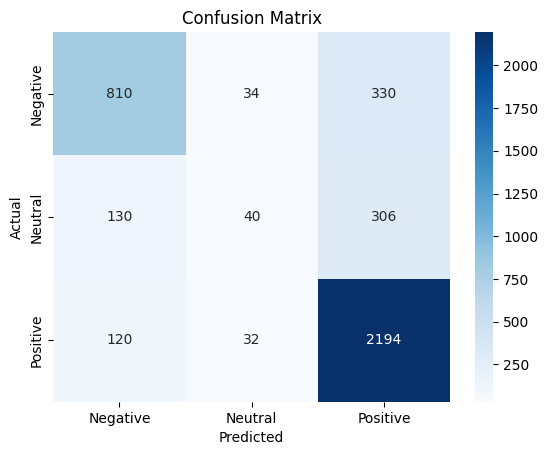

In [38]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()